In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive/colab')

['placement_predict_50k Dataset.csv', 'placement_dataset.csv']

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/colab/placement_dataset.csv')

Iteration    0 | Loss: 27.1394
Iteration  100 | Loss: 3.5957
Iteration  200 | Loss: 0.5039
Iteration  300 | Loss: 0.0894
Iteration  400 | Loss: 0.0338
Iteration  500 | Loss: 0.0263
Iteration  600 | Loss: 0.0252
Iteration  700 | Loss: 0.0251
Iteration  800 | Loss: 0.0250
Iteration  900 | Loss: 0.0250

Final weights (theta):
[ 7.29885264e+00  1.51572915e-01  6.19255015e-02  9.18994042e-02
  6.11528698e-02  9.21034270e-02  3.59116610e-02  1.42812012e-01
  1.53586067e-01  1.62139076e-01  1.37183398e-01  2.54455045e-02
 -3.15083847e-04]

Test MSE : 0.0502
Test R^2 : 0.9508

sklearn LinearRegression R^2: 0.9508

Saved plots to gradient_descent_plots.png


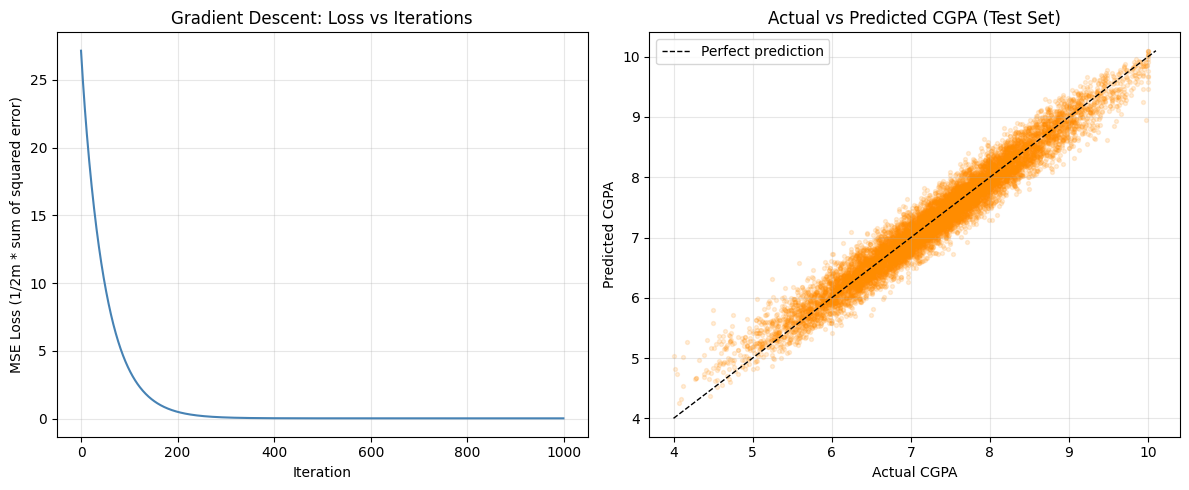

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ---------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------
df = pd.read_csv("/content/drive/MyDrive/colab/placement_predict_50k.csv")

target_col = "CGPA"


sgpa_cols = [f"SGPA_Sem{i}" for i in range(1, 9)]
drop_cols = [c for c in [target_col, "StudentID", "CGPA_Tier"] + sgpa_cols if c in df.columns]
feature_df = df.drop(columns=drop_cols).select_dtypes(include=[np.number])


feature_df = feature_df.fillna(feature_df.median())

X = feature_df.values
y = df[target_col].values.reshape(-1, 1)

# ---------------------------------------------------------
# 2. Train/test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------------
# 3. Feature scaling (helps gradient descent converge)
# ---------------------------------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Add bias column (intercept term)
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# ---------------------------------------------------------
# 4. Gradient Descent implementation
# ---------------------------------------------------------
def gradient_descent(X, y, lr=0.01, n_iters=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    losses = []

    for i in range(n_iters):
        y_pred = X @ theta
        error = y_pred - y

        # Mean Squared Error loss
        loss = (1 / (2 * m)) * np.sum(error ** 2)
        losses.append(loss)

        # Gradient of MSE w.r.t. theta
        gradient = (1 / m) * (X.T @ error)

        # Update rule
        theta -= lr * gradient

        if i % 100 == 0:
            print(f"Iteration {i:4d} | Loss: {loss:.4f}")

    return theta, losses

theta, losses = gradient_descent(X_train_b, y_train, lr=0.01, n_iters=1000)

# ---------------------------------------------------------
# 5. Evaluate
# ---------------------------------------------------------
y_pred = X_test_b @ theta

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nFinal weights (theta):")
print(theta.ravel())
print(f"\nTest MSE : {mse:.4f}")
print(f"Test R^2 : {r2:.4f}")

# ---------------------------------------------------------
# 6. (Optional) Compare with sklearn's LinearRegression
# ---------------------------------------------------------
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)

print(f"\nsklearn LinearRegression R^2: {r2_score(y_test, sk_pred):.4f}")

# ---------------------------------------------------------
# 7. Plots
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Gradient descent loss curve — shows convergence over iterations
axes[0].plot(range(len(losses)), losses, color="steelblue")
axes[0].set_title("Gradient Descent: Loss vs Iterations")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE Loss (1/2m * sum of squared error)")
axes[0].grid(alpha=0.3)

# (b) Actual vs Predicted CGPA on the test set
axes[1].scatter(y_test, y_pred, alpha=0.15, s=8, color="darkorange")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, color="black", linestyle="--", linewidth=1, label="Perfect prediction")
axes[1].set_title("Actual vs Predicted CGPA (Test Set)")
axes[1].set_xlabel("Actual CGPA")
axes[1].set_ylabel("Predicted CGPA")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("gradient_descent_plots.png", dpi=150)
print("\nSaved plots to gradient_descent_plots.png")
plt.show()

In [ ]:
import os
os.listdir('/content/drive/MyDrive/colab')

['placement_predict_50k Dataset.csv',
 'placement_dataset.csv',
 'placement_predict_50k.csv']

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/colab/placement_dataset.csv')

In [ ]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/colab/placement_dataset.csv")

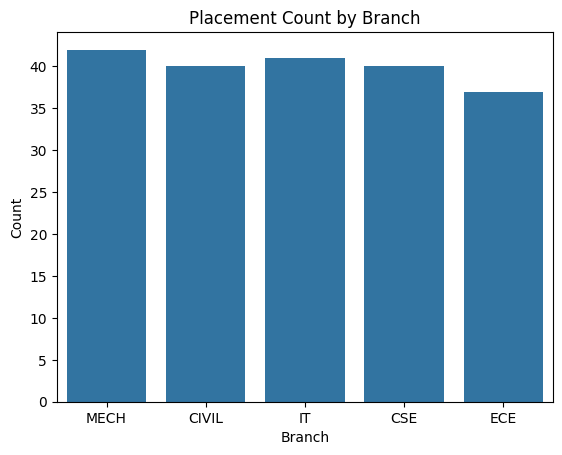

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Branch")

plt.title("Placement Count by Branch")
plt.xlabel("Branch")
plt.ylabel("Count")

plt.show()

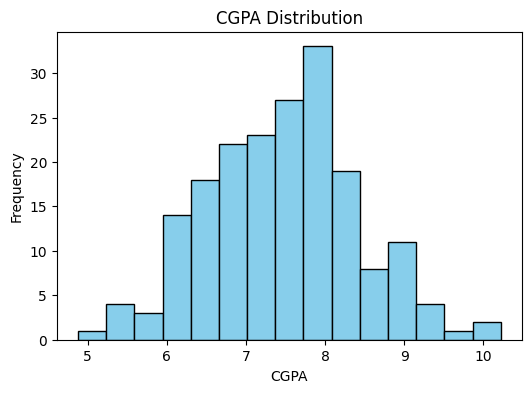

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(df["CGPA"].dropna(),
         bins=15,
         color="skyblue",
         edgecolor="black")

plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Frequency")

plt.show()

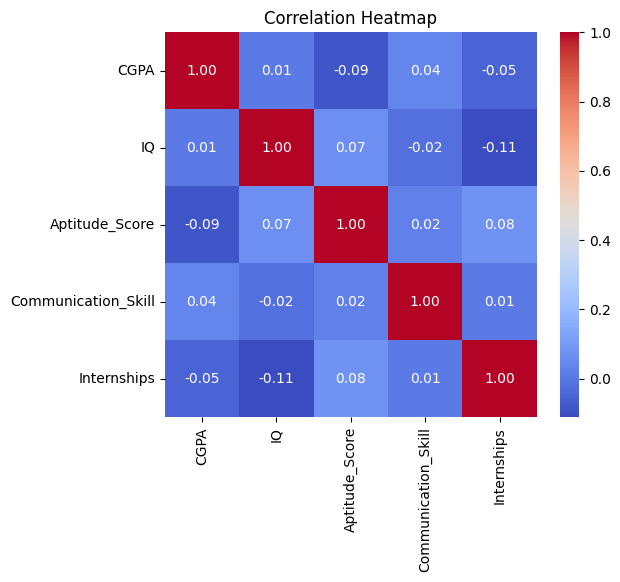

In [ ]:
plt.figure(figsize=(6,5))

numeric_df = df.select_dtypes(include="number")

corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

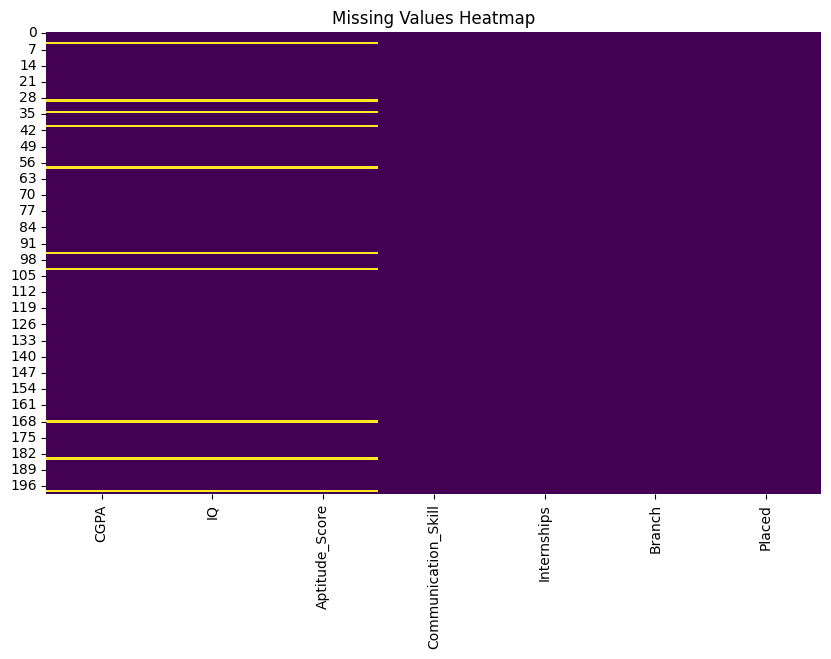

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()